In [ ]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/dataset_PDS/data_suhu_kelembapan.csv"
df = pd.read_csv(file_path, encoding='latin1')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

# Load dataset
# data = pd.read_csv("data_suhu_kelembapan.csv") # This line is commented out

# Use the dataframe already loaded in the previous cell
data = df

# Tampilkan 5 baris awal
print(data.head())

# Cek informasi umum
print(data.info())

# Cek missing value
print(data.isnull().sum())

   Timestamp (ms)  Humidity (%)  Temperature (°F)  Temperature (°C)
0               0         43.70             76.64             24.80
1            2000         45.26             76.56             24.76
2            4000         44.97             76.70             24.83
3            6000         45.96             78.22             25.68
4            8000         46.24             78.51             25.84
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp (ms)    5400 non-null   int64  
 1   Humidity (%)      5400 non-null   float64
 2   Temperature (°F)  5400 non-null   float64
 3   Temperature (°C)  5400 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 168.9 KB
None
Timestamp (ms)      0
Humidity (%)        0
Temperature (°F)    0
Temperature (°C)    0
dtype: int64


a

In [ ]:
# Tujuan: Membuat model untuk memprediksi suhu berdasarkan kelembapan
# Target: suhu
# Fitur: kelembapan
X = data[['Humidity (%)']]
y = data['Temperature (°C)']

b

Linear regression adalah salah satu algoritma yang digunakan data science dan tergolong pada algoritma supervised learning. Algoritma ini menggunakan prinsip regresi. Regresi membuat model prediksi untuk target variabel berdasarkan dari variabel bebasnya. Jenis algoritma ini sering digunakan untuk mencari hubungan antara variabel-variabel yang ada dan prediksinya. Sehingga pada linear regression, ditujukan untuk melakukan prediksi pada variabel terikat (y) berdasarkan variabel bebas yang diberikan (x). Hasil akhirnya berupa hubungan linear antara variabel input (x) dengan variabel output(y).

|=======================================================================|


Algoritma Linear Regression dipilih karena sesuai untuk memodelkan hubungan linier antara kelembapan dan suhu, mudah diinterpretasikan, cepat dilatih, serta dapat dijadikan model dasar untuk evaluasi awal performa prediksi data sensor.

In [ ]:
X = data[['Humidity (%)']]   # variabel independen
y = data['Temperature (°C)'] # variabel dependen

c

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
train_pct = len(X_train) / len(X) * 100
test_pct  = len(X_test) / len(X) * 100

print(f"Persentase data train: {train_pct:.2f}%")
print(f"Persentase data test : {test_pct:.2f}%")


Persentase data train: 80.00%
Persentase data test : 20.00%


In [ ]:
print("Jumlah data total:", len(X))
print("Jumlah data train:", len(X_train))
print("Jumlah data test :", len(X_test))


Jumlah data total: 5400
Jumlah data train: 4320
Jumlah data test : 1080


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Evaluasi Model Linear Regression ===")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")


=== Evaluasi Model Linear Regression ===
MAE  : 0.444
RMSE : 0.804
R²   : -0.003


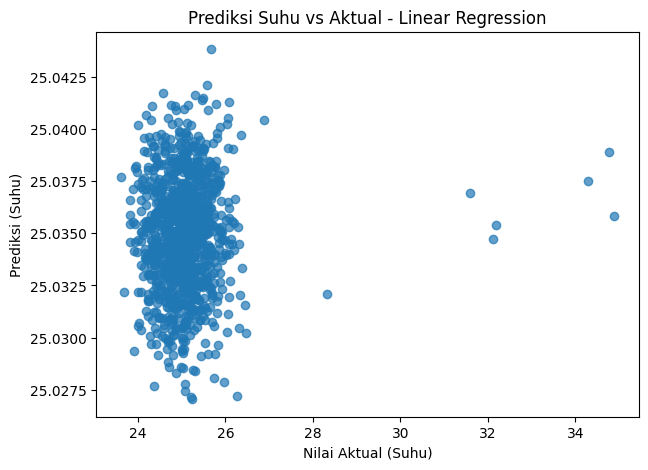

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Nilai Aktual (Suhu)")
plt.ylabel("Prediksi (Suhu)")
plt.title("Prediksi Suhu vs Aktual - Linear Regression")
plt.show()

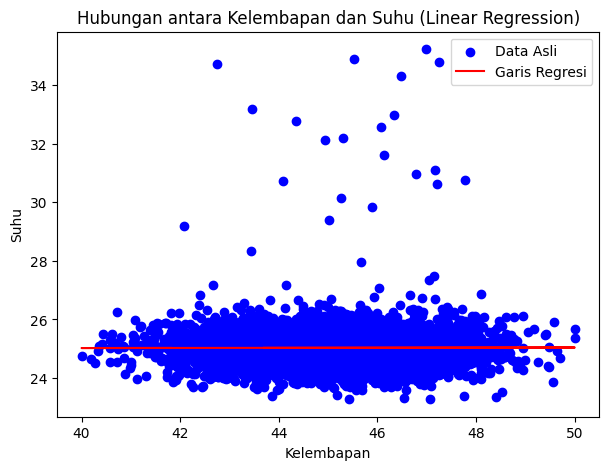

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X, y, color='blue', label='Data Asli')
plt.plot(X, model.predict(X), color='red', label='Garis Regresi')
plt.xlabel('Kelembapan')
plt.ylabel('Suhu')
plt.title('Hubungan antara Kelembapan dan Suhu (Linear Regression)')
plt.legend()
plt.show()